# Método da Bisseção

## Ideia do método

Desejamos encontrar uma aproximação $\bar{x}$ para a raiz $\xi$ de uma função

$
f(x)=0
$

Sabemos que

$
\xi \in [a,b]
$

e que

$
f(a)\cdot f(b)<0.
$

A cada iteração:

- calculamos o ponto médio

$
x=\frac{a+b}{2}
$

- escolhemos a metade do intervalo que contém a raiz;
- repetimos o processo até atingir a precisão desejada $\varepsilon$.

## Algoritmo

```text
Entrada:
    intervalo inicial [a,b]
    precisão ε
    número máximo de iterações K

k = 0

enquanto (b − a ≥ ε) e (k < K)

    x = (a + b) / 2

    se f(a) · f(x) < 0
        b = x
    senão
        a = x

    k = k + 1

retorne (a + b) / 2
```

In [ ]:
import math

def bissecao(f,a,b,eps=1e-3,kmax=100):
    k=0
    while (b-a)>=eps and k<kmax:
        if f(a)*f(x)<0:
            b=x
        else:
            a=x
        k+=1
    x=(a+b)/2
    return x, k


## Exemplo 1

$
f(x)=x^2-2,\qquad [a,b]=[1,2],\qquad \varepsilon=0,1.
$

In [ ]:
f=lambda x: x**2 - 2
bissecao(f,1,2,eps=0.1)

(1.40625, 4)

## Exemplo 2

$
f(x)=x^3-9x+3,\qquad [a,b]=[0,1],\qquad \varepsilon=10^{-3}.
$

In [ ]:
f=lambda x:x**3 -9*x + 3
bissecao(f,0,1,eps=1e-3)

(0.33740234375, 10)

## Exercício

$
f(x)=x^3-x-2,\qquad [a,b]=[1,2],\qquad \varepsilon=0,2.
$

In [10]:
f = lambda x: x**3 - x - 2
bissecao(f, 1, 2, eps=0.2)

(1.5625, 3)

## Análise da Convergência

A seguir registramos o histórico das iterações para construir tabelas e visualizar a convergência do método.

In [32]:
def bissecao_historico(f, a, b, eps=1e-3, kmax=100):
    ks = []
    As = []
    Bs = []
    Xs = []
    A1s = []
    B1s = []

    k = 0

    while (b - a) >= eps and k < kmax:
        a0 = a
        b0 = b

        x = (a + b) / 2

        if f(a) * f(x) < 0:
            b = x
        else:
            a = x

        ks.append(k + 1)
        As.append(a0)
        Bs.append(b0)
        Xs.append(x)
        A1s.append(a)
        B1s.append(b)

        k += 1

    return ks, As, Bs, Xs, A1s, B1s

In [33]:
f = lambda x: x**3 - x - 2

k, a, b, x, a_novo, b_novo = bissecao_historico(f, 1, 2, eps=0.2)

In [34]:
import pandas as pd

df = pd.DataFrame({
    "k": k,
    "a": a,
    "b": b,
    "x": x,
    "a'": a_novo,
    "b'": b_novo,
})

df["f(x)"] = df["x"].apply(f)
df["b' - a'"] = df["b'"] - df["a'"]

df.head()


,k,a,b,x,a',b',f(x),b' - a'
0,1,1.0,2.00,1.500,1.5,2.000,-0.125000,0.500
1,2,1.5,2.00,1.750,1.5,1.750,1.609375,0.250
2,3,1.5,1.75,1.625,1.5,1.625,0.666016,0.125


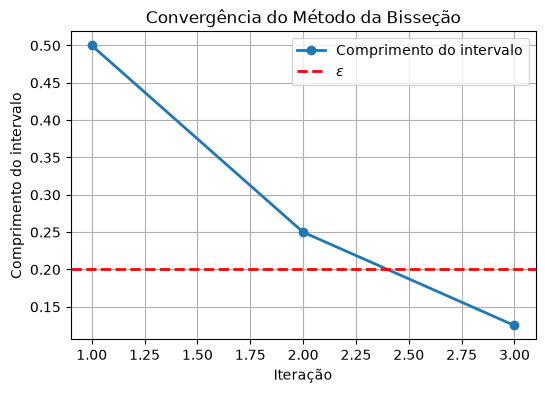

In [37]:
import matplotlib.pyplot as plt

df["L"] = df["b'"] - df["a'"]

plt.figure(figsize=(6,4))

plt.plot(df["k"], df["L"], marker="o", linewidth=2, label="Comprimento do intervalo")

plt.axhline(y=0.2, color="red", linestyle="--", linewidth=2, label=r"$\varepsilon$")

plt.xlabel("Iteração")
plt.ylabel("Comprimento do intervalo")
plt.title("Convergência do Método da Bisseção")

plt.grid(True)
plt.legend()

plt.show()